# Figure S3 - mutational behaviour and the genotype-to-antigenic map

Reviewer 1, comment 1a stacks two claims:

- **(a)** the same substitution gets different antigenic directions in different backgrounds — **true, and conceded**;
- **(b)** *"two similar viruses that acquire this given change should cluster together"* — **testable, and it fails as a criticism**.

Panels **A** and **B** characterise the simulation's mutational behaviour and answer (a): independent recurrence is common, lineage reversion is rare. Panels **C** and **D** answer (b) directly, and are the load-bearing result — genotype predicts antigenic position tightly, because antigenic position is the cumulative sum of every mutation along a lineage rather than the effect of any single one.

Every panel is a distribution over **all** swept simulations, not one representative build, which removes the cherry-picking objection.

Inputs are the tables written by `scripts/sweep_mutation_homoplasy.py` (submitted via `scripts/submit_homoplasy_sweep.sh`, since the per-run Auspice trees exist only on the cluster). See `specs/mutation_homoplasy.md` for the method, including why the similar-background null must be *matched* to its statistic, and why panel D needs the full rather than the deduplicated tip table.

## Imports and parameters

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

HERE = Path.cwd()
sys.path.append(str(HERE.parent / 'scripts'))

from plot_mutation_homoplasy import (
    RC_PARAMS,
    REPRESENTATIVE_RUN,
    build_across_run_figure,
)
from antigentools.supplement_style import apply_supplement_style

# Match the styling of the other aggregated supplement figures (S4, S5) rather
# than setting rcParams inline here; the definition lives in one module now.
apply_supplement_style()

BATCH = '2026-07-04-reviewer-runs'
AGG_DIR = HERE.parent / 'results' / 'aggregated' / BATCH
CAND_PATH = HERE.parent / 'data' / BATCH / 'antigen-outputs' / 'candidate_runs.csv'
FIG_DIR = HERE.parent.parent / 'antigen-tex' / 'reviews' / 'round1' / 'figures'

# The unfiltered progeny threshold is the headline; the sweep also emits a
# filtered one as the control against transient origins.
MIN_ORIGIN_PROGENY = 1
FIG_PREFIX = 'figureS3_mutation_homoplasy'

## Load the sweep output and restrict to the flu-like candidate runs

The sweep covers every run that has a tree; filtering to the candidates happens here, using the same `cand_keys` idiom as figures S4 and S6.

In [2]:
summary = pd.read_csv(AGG_DIR / 'mutation_homoplasy_by_run.csv')
genotype = pd.read_csv(AGG_DIR / 'genotype_antigenic_by_distance.csv')
similar = pd.read_csv(AGG_DIR / 'mutation_homoplasy_similar_background_by_k.csv')

cand = pd.read_csv(CAND_PATH)


def config_from_path(p):
    m = re.search(r'simulations/([^/]+)/run_', p)
    assert m is not None, f'cannot parse config from candidate path: {p!r}'
    return m.group(1)


cand['config'] = cand['path'].map(config_from_path)
cand_keys = set(zip(cand['config'], cand['run'].astype(int)))


def keep_candidates(df, label):
    keys = list(zip(df['config'], df['run'].astype(int)))
    kept = df[[k in cand_keys for k in keys]].copy()
    assert not kept.empty, f'no candidate runs survived the join for {label}'
    print(f'{label}: {len(kept)} rows from {kept.groupby(["config", "run"]).ngroups} candidate runs')
    return kept


summary = keep_candidates(summary, 'per-run summary')
genotype = keep_candidates(genotype, 'genotype-antigenic curve')
similar = keep_candidates(similar, 'similar-background counts')
similar = similar[similar['min_origin_progeny'] == MIN_ORIGIN_PROGENY]

# Report the two degradations separately rather than lumping them: a run without a
# usable FASTA has tree-only numbers, while a run that merely lacks the full
# tips.csv is missing only panel D's statistic.
notes = summary['notes'].fillna('')
print(f"tree-only (no FASTA): {notes.str.contains('sequence stats failed').sum()} of {len(summary)}")
print(f"no full tips.csv (panel D only): {notes.str.contains('no full tips.csv').sum()} of {len(summary)}")

per-run summary: 40 rows from 40 candidate runs
genotype-antigenic curve: 200 rows from 40 candidate runs
similar-background counts: 3840 rows from 40 candidate runs
tree-only (no FASTA): 0 of 40
no full tips.csv (panel D only): 0 of 40


## Figure S3

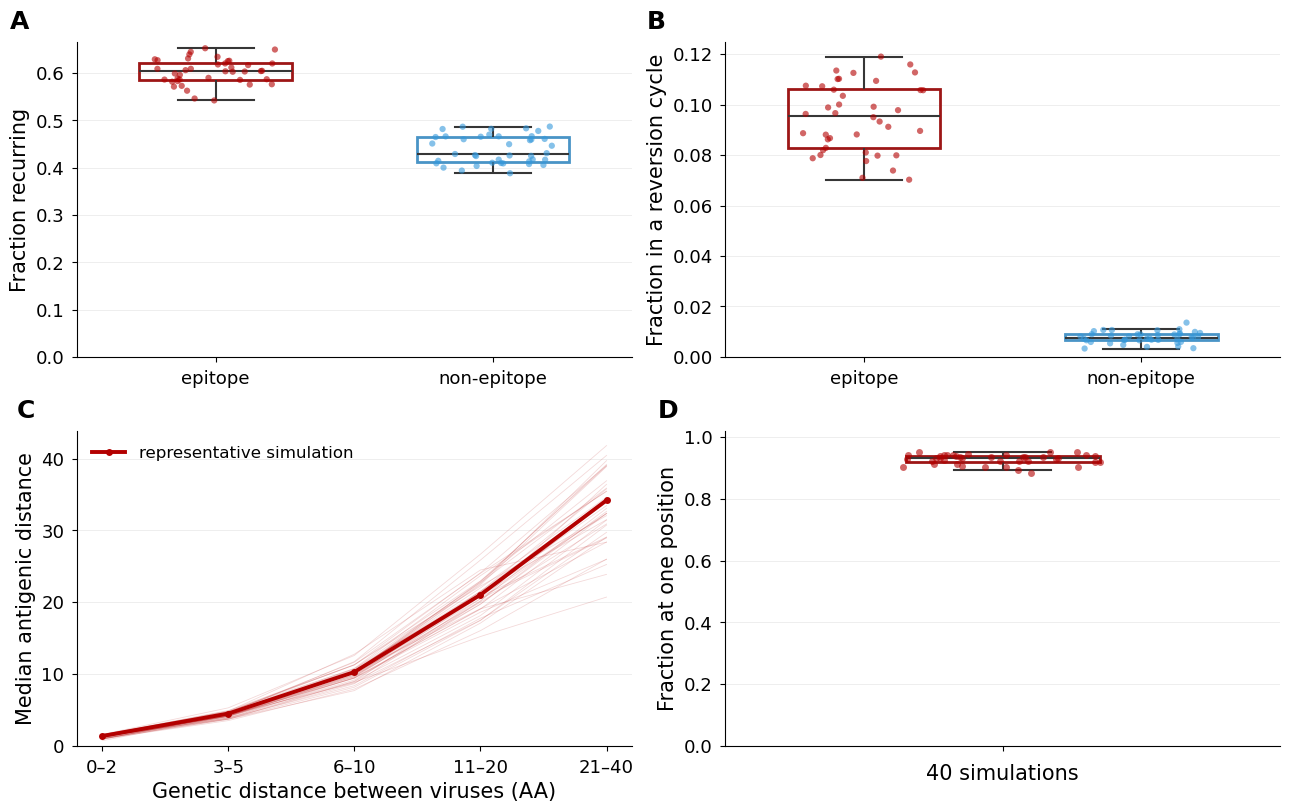

In [3]:
with plt.rc_context(RC_PARAMS):
    fig = build_across_run_figure(summary, genotype, REPRESENTATIVE_RUN)
plt.show()

In [4]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
for suffix in ('pdf', 'png'):
    path = FIG_DIR / f'{FIG_PREFIX}.{suffix}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Wrote {path}')

Wrote /Users/zo/projects/research/antigen-tex/reviews/round1/figures/figureS3_mutation_homoplasy.pdf


Wrote /Users/zo/projects/research/antigen-tex/reviews/round1/figures/figureS3_mutation_homoplasy.png


**Figure S3.** Mutational behaviour and the genotype-to-antigenic map across all flu-like candidate `antigen-prime` simulations. Each point is one simulation.

**(A)** Fraction of distinct amino-acid substitutions that arise independently on two or more branches of the inferred tree, by site class. Independent recurrence is common, and the response does not claim otherwise.

**(B)** Fraction of substitutions participating in a gain-then-loss cycle along a single lineage, i.e. where the exact reverse substitution arises on a branch strictly below a forward origin. This is the quantity relevant to time-reversibility, and unlike recurrence it is rare. Counts are directed: a substitution and its reverse are two keys but one reversible pair. The excess at epitope sites is a consequence of substitution density, since only 49 sites accumulate 6.6 distinct substitutions each against 3.0 elsewhere, and reversion probability grows steeply with that density.

**(C)** Median antigenic distance between pairs of viruses, binned by the amino-acid distance between them. Faint lines are individual simulations, the bold line their median. Genotype predicts antigenic position tightly despite the antigenic direction being drawn independently for each mutation event, because a virus's antigenic position is the cumulative sum of every mutation along its lineage: two genetically similar viruses share nearly all of that displacement, and the per-event randomness perturbs a single step of roughly 0.3 units against a span of about 40.

**(D)** Fraction of amino-acid sequences carried by more than one virus whose carriers all occupy a single antigenic position. Computed from the full, non-deduplicated tip table, since `unique_tips.csv` collapses exactly the repeat structure being measured. The denominator is sequences rather than tips because the assignment methods are handed the deduplicated table and so encounter each distinct sequence once.

## Numbers quoted in the response letter

Pooled across candidate runs, weighting by counts rather than averaging per-run fractions (runs differ in size, and the parameter configs have unequal numbers of replicates).

In [5]:
def pooled(numerator, denominator):
    return summary[numerator].sum() / summary[denominator].sum()


print('--- panels A and B ---')
for site_class in ('epitope', 'non_epitope'):
    rec = pooled(f'n_recurrent_{site_class}', f'n_substitutions_{site_class}')
    rev = pooled(f'n_lineage_cycle_{site_class}', f'n_substitutions_{site_class}')
    print(f'{site_class:12s} recurrence {rec:6.1%}   lineage reversion {rev:6.1%}')

print('\n--- panels C and D ---')
r = summary['genotype_antigenic_pearson'].dropna()
print(f'genotype-antigenic Pearson r: median {r.median():.3f}  range {r.min():.3f}-{r.max():.3f}')
spreading = summary['frac_shared_sequences_spreading'].dropna()
tipwise = summary['frac_tips_in_spreading_group'].dropna()
mag = summary['identical_seq_spread_median_when_spreading'].dropna()
print(f'shared sequences at ONE antigenic position: {1 - spreading.median():.1%} (median over runs)')
print(f'  same figure weighted by tips instead:      {1 - tipwise.median():.1%}')
print(f'  median separation where they do differ:    {mag.median():.2f} of a ~{summary["antigenic_span"].median():.0f} unit span')

print('\n--- supporting: similar-background recurrence (appendix only, no longer a panel) ---')
pooled_similar = (
    similar[similar['statistic'] == 'two_origins']
    .groupby(['site_class', 'k'])[['n_within_k', 'n_total', 'n_null_within_k', 'n_null_total']]
    .sum()
)
pooled_similar['observed'] = pooled_similar['n_within_k'] / pooled_similar['n_total']
pooled_similar['matched_null'] = (
    pooled_similar['n_null_within_k'] / pooled_similar['n_null_total']
)
print((100 * pooled_similar[['observed', 'matched_null']]).round(1).to_string())

--- panels A and B ---
epitope      recurrence  60.3%   lineage reversion   9.5%
non_epitope  recurrence  44.1%   lineage reversion   0.8%

--- panels C and D ---
genotype-antigenic Pearson r: median 0.946  range 0.876-0.973
shared sequences at ONE antigenic position: 93.1% (median over runs)
  same figure weighted by tips instead:      82.8%
  median separation where they do differ:    1.23 of a ~41 unit span

--- supporting: similar-background recurrence (appendix only, no longer a panel) ---
               observed  matched_null
site_class  k                        
epitope     1       8.4           7.2
            2      17.6          12.7
            3      26.7          18.7
            4      35.1          25.1
            5      42.9          31.4
            6      50.5          37.6
            7      56.5          43.7
            8      62.5          49.7
non_epitope 1       2.3           7.2
            2       8.3          12.7
            3      14.9          18.8
      